# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Load Dataset

In [2]:
# Load dataset from Downloads folder
df = pd.read_csv(r"C:\Users\PMLS\Downloads\Titanic-Dataset.csv")

# View first few rows
df.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Exploratory Data Analysis

In [3]:
# Check number of rows and columns
print(df.shape)

# Get column data types and non-null counts
print(df.info())

# Get basic statistics for numerical columns
print(df.describe())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


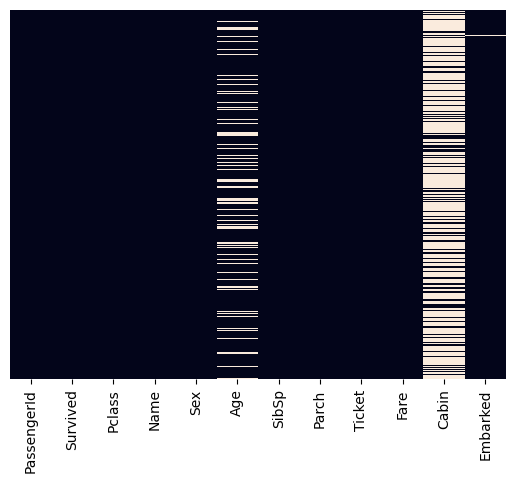

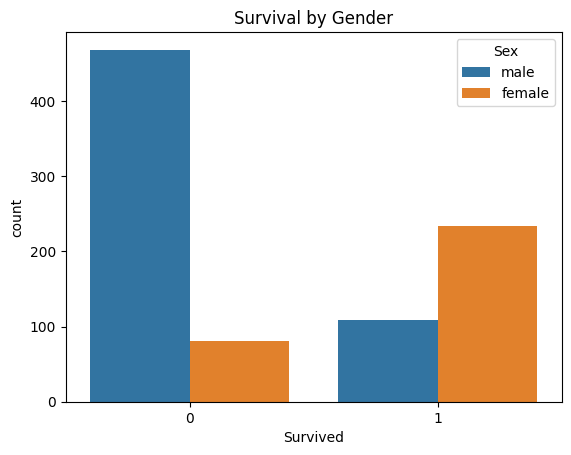

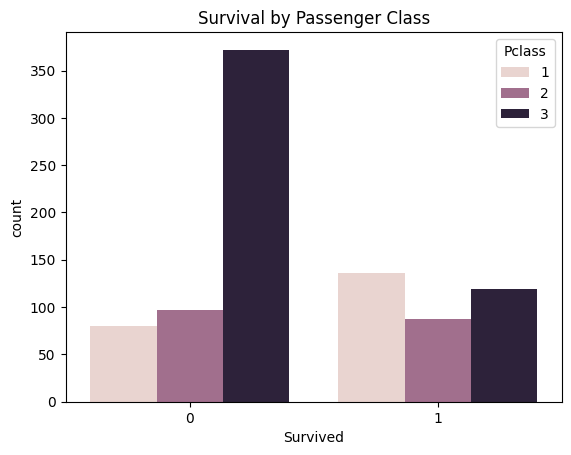

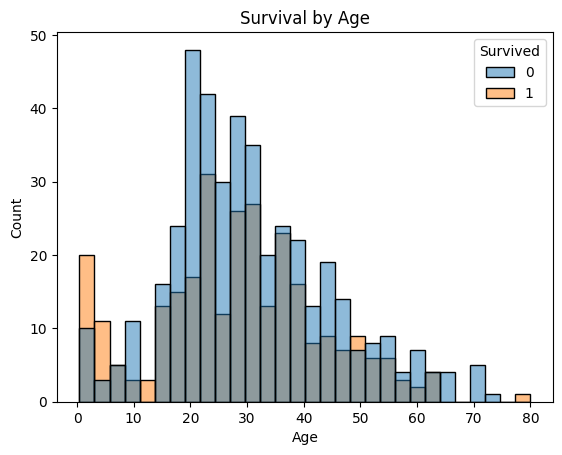

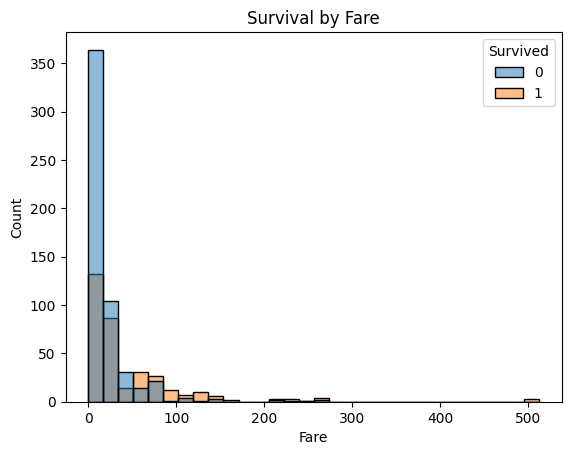

In [4]:
# Check missing values for each column
print(df.isnull().sum())

# Optional: visualize missing values
import seaborn as sns
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.show()

sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival by Gender')
plt.show()

sns.countplot(x='Survived', hue='Pclass', data=df)
plt.title('Survival by Passenger Class')
plt.show()

sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=False) #bins counts num of bars
plt.title('Survival by Age')
plt.show()

sns.histplot(data=df, x='Fare', hue='Survived', bins=30, kde=False)
plt.title('Survival by Fare')
plt.show()


In [5]:
# Fill Age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill Embarked
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df.columns




Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
# Drop Cabin
df = df.drop('Cabin', axis=1)

# Drop unnecessary columns
df = df.drop(['Name', 'Ticket', 'PassengerId'], axis=1)

df.columns


Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

# Feature Engineering

In [7]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
#Converts Sex from text (male/female) to numbers (0/1).

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
#Embarked → One-Hot Encoding

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
#Explanation:

#FamilySize = number of siblings/spouses + parents/children + self.

#Reasoning:

#Family presence may affect survival: alone vs. with family.

df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

#Explanation:

#If FamilySize = 1 → passenger is alone → IsAlone = 1, else 0.

#Reasoning:

#Being alone could reduce survival chances.

df = df.drop(['SibSp', 'Parch'], axis=1)
#SibSp & Parch are now represented in FamilySize and IsAlone, so dropping prevents redundancy.




In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

#Explanation:

#StandardScaler → subtract mean, divide by std deviation → standard normal distribution.

#Important for distance-based models like KNN, SVM.

# Test/Train Split

In [9]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Survived', axis=1)
y = df['Survived']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape


((712, 8), (179, 8))

# Train and Predict Logistic Regression

In [10]:
from sklearn.linear_model import LogisticRegression

# Create the model
model = LogisticRegression(max_iter=1000)

# Train/Fit the model
model.fit(X_train, y_train)

# Predict on test data
log_pred = model.predict(X_test)


# Train and Predict Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    random_state=42     # ensures reproducibility
)

# Train/Fit the model
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)


# Train and Predict KNN 

In [12]:
from sklearn.neighbors import KNeighborsClassifier

# Create model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train/Fit the model
knn_model.fit(X_train, y_train)

# Predict
knn_pred = knn_model.predict(X_test)


# Logistic Regression Performance Metrics

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [14]:
# Accuracy
log_acc = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy:", log_acc)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, log_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, log_pred))


Logistic Regression Accuracy: 0.7988826815642458
Confusion Matrix:
 [[90 15]
 [21 53]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.86      0.83       105
           1       0.78      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# Random Forest Performance Metrics

In [15]:
# Accuracy
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8324022346368715
Confusion Matrix:
 [[90 15]
 [15 59]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179



# KNN Performance Metrics

In [16]:
# Accuracy
knn_acc = accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, knn_pred))

# Classification Report
print("Classification Report:\n", classification_report(y_test, knn_pred))


KNN Accuracy: 0.8324022346368715
Confusion Matrix:
 [[93 12]
 [18 56]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86       105
           1       0.82      0.76      0.79        74

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



# Models Comparision

In [17]:
print("Model Comparison:")
print("Logistic Regression:", log_acc)
print("Random Forest:", rf_acc)
print("KNN:", knn_acc)


Model Comparison:
Logistic Regression: 0.7988826815642458
Random Forest: 0.8324022346368715
KNN: 0.8324022346368715


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


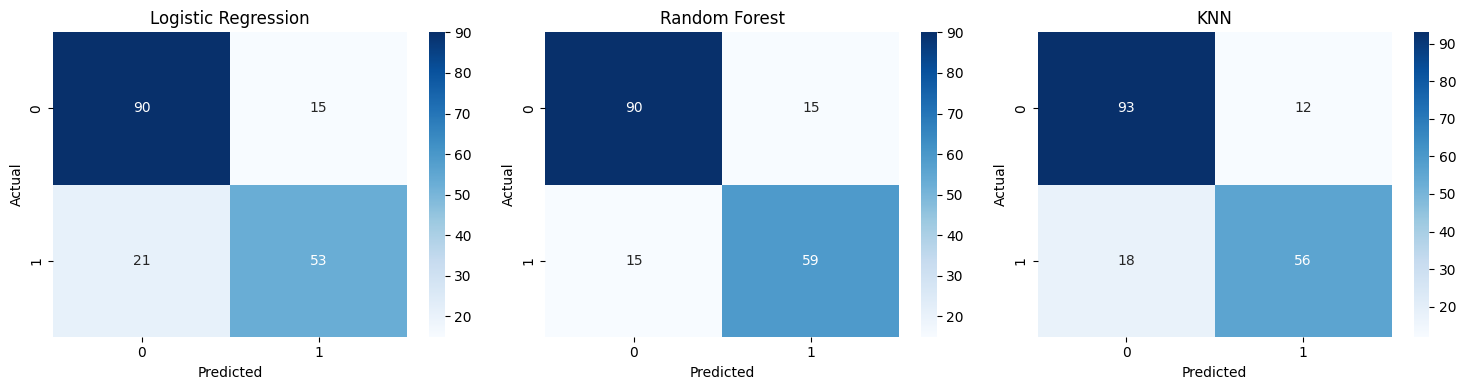

In [19]:
models = ['Logistic Regression', 'Random Forest', 'KNN']
predictions = [log_pred, rf_pred, knn_pred]

plt.figure(figsize=(15, 4))

for i, (name, pred) in enumerate(zip(models, predictions)):
    cm = confusion_matrix(y_test, pred)
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()


C:\Users\PMLS\AppData\Local\Temp\ipykernel_6292\2623603052.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette=colors)


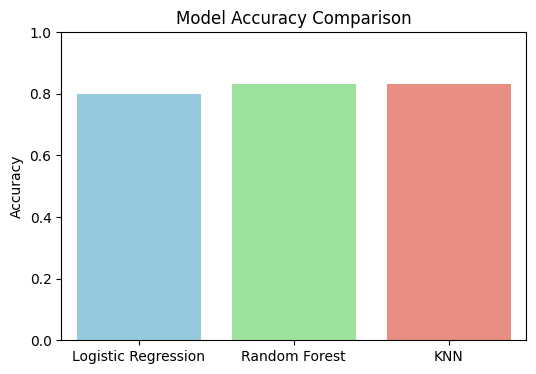

In [20]:
from sklearn.metrics import accuracy_score

accuracies = [
    accuracy_score(y_test, log_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, knn_pred)
]

# Define colors for each bar
colors = ['skyblue', 'lightgreen', 'salmon']

# Create the bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x=models, y=accuracies, palette=colors)
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()


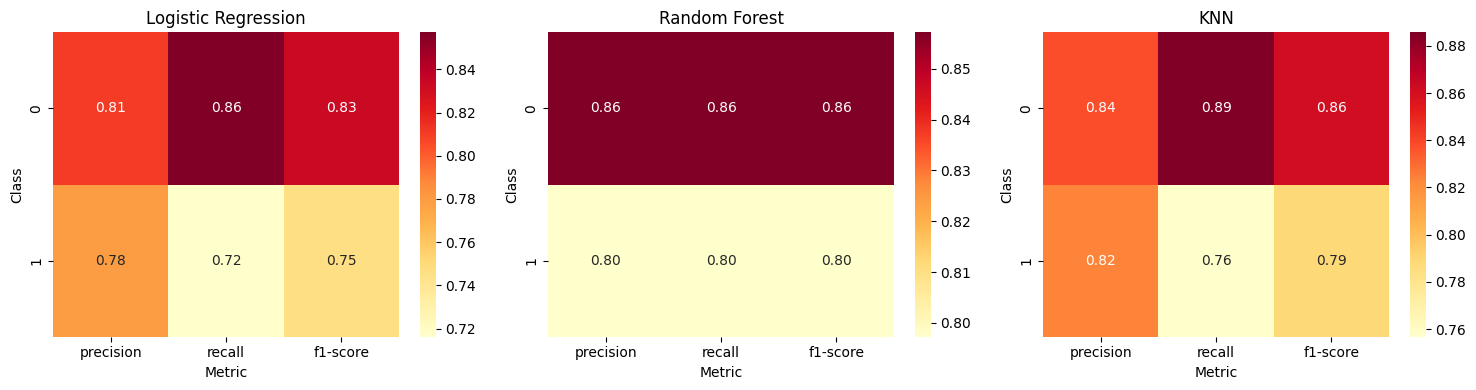

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report

models = ['Logistic Regression', 'Random Forest', 'KNN']
predictions = [log_pred, rf_pred, knn_pred]

# Create a single figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, pred in zip(axes, models, predictions):
    # Get classification report
    report = classification_report(y_test, pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    
    # Keep only per-class metrics
    df_report = df_report.loc[['0','1'], ['precision','recall','f1-score']]
    
    # Plot heatmap on the current axis
    sns.heatmap(df_report, annot=True, cmap='YlOrRd', fmt='.2f', ax=ax)
    ax.set_title(name)
    ax.set_ylabel('Class')
    ax.set_xlabel('Metric')

plt.tight_layout()
plt.show()
